In [1]:
from sklearn import metrics
import torch
import copy
import os
import random
import numpy as np
from semanticst.loading_batches import PrepareDataloader
from semanticst.loading_batches import Dataloader
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import torch.utils.data as data
from semanticst.main import Config
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
BASE_PATH = Path('/home/roxana/Projects/SemanticST/Rod_week2/Rod_week2_cell_type_new.h5ad')
#BASE_PATH = Path('//home/roxana/Projects/Data/Implants_data/sphere_wk2_diet.h5ad')
spot_paths= Path(f'{BASE_PATH}')
adata = sc.read_h5ad(spot_paths)
sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)

adata.var_names_make_unique()

In [3]:
adata

AnnData object with n_obs × n_vars = 1489 × 19242
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'domain', 'domain_annot', 'cell_type'
    var: 'MoransI_observed', 'MoransI_p.value', 'moransi.spatially.variable', 'moransi.spatially.variable.rank'
    uns: 'domain_annot_colors', 'louvain_colors', 'log1p'
    obsm: 'X_spatial_coords', 'spatial'

In [4]:
dtype = "Visium"  # Change to "h5ad" if necessary
config=Config(device=device,dtype=dtype, use_mini_batch=False)
from semanticst.SemanticST_main import Semantic as Trainer
config_used = copy.copy(config)
model = Trainer(adata,config)  
adata=model.train()  # Train the model



🚀 Welcome to SemanticST! 🚀

📢 Recommendation: If your dataset contains more than 40000 spots or cells, we suggest using **mini-batch training** for efficiency.

✅ Using Full Dataset Training (No Mini-Batching). 🔥
Begin to train ST data...


Learning Semantic graphs: 100%|████████████| 250/250 [00:11<00:00, 21.91epoch/s]


Semantic Graph Learning Completed


Feature Learning Epochs: 100%|██████████████| 1000/1000 [01:01<00:00, 16.30it/s]


In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, random_state=1) 
embedding = pca.fit_transform(adata.obsm['emb_decoder'].copy())
adata.obsm['emb_pca'] = embedding
sc.pp.neighbors(adata, use_rep='emb_pca')
sc.tl.umap(adata)

In [6]:
sc.tl.leiden(adata, random_state=0, resolution=0.9)

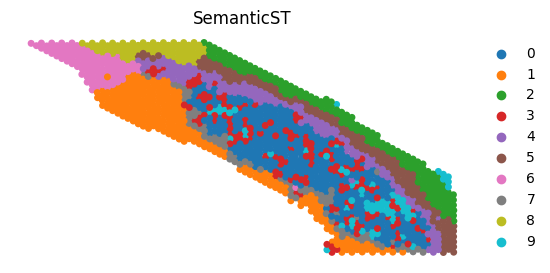

In [7]:
plt.rcParams["figure.figsize"] = (6, 3)
fig, ax = plt.subplots()
sc.pl.embedding(adata, basis="spatial", color="leiden",s=100, ax=ax,show=False, title='SemanticST')
plt.axis('off')
plt.gca().invert_yaxis() 

#fig.savefig("sEMANTIC_seqfish_leiden_dt_mouse_brain.png", dpi=600,bbox_inches='tight')
plt.show()

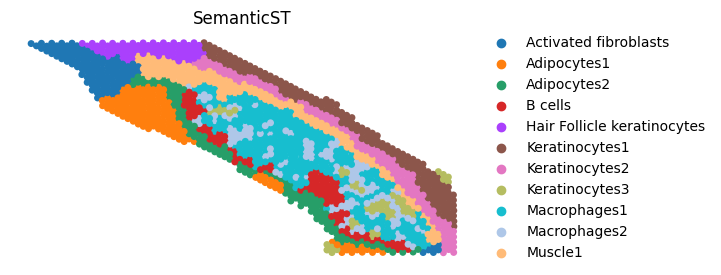

In [13]:
plt.rcParams["figure.figsize"] = (6, 3)
fig, ax = plt.subplots()
sc.pl.embedding(adata, basis="spatial", color="cell_type",s=100, ax=ax,show=False, title='SemanticST')
plt.axis('off')
plt.gca().invert_yaxis() 

#fig.savefig("sEMANTIC_seqfish_leiden_dt_mouse_brain.png", dpi=600,bbox_inches='tight')
plt.show()